<a href="https://colab.research.google.com/github/Aaryan8597/AI-ML-AaryanLamichhane2408597-/blob/main/Worksheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Identifying version of keras

In [39]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


# Manual Gradient Calculation in Numpy

In [40]:
import numpy as np
def f(x): #simple function f(x) = X^2
  return x ** 2
def gradient(x): # manual derivative
  return 2 * x

#update rule x = x - learning rate * gradient
x = 5.0
learning_rate = 0.1
for _ in range(10): # optimizing for 10 steps
  x -= learning_rate * gradient(x)
  print(f"x: {x}: {f(x)}")

x: 4.0: 16.0
x: 3.2: 10.240000000000002
x: 2.56: 6.5536
x: 2.048: 4.194304
x: 1.6384: 2.68435456
x: 1.31072: 1.7179869184000003
x: 1.0485760000000002: 1.0995116277760004
x: 0.8388608000000002: 0.7036874417766403
x: 0.6710886400000001: 0.45035996273704976
x: 0.5368709120000001: 0.2882303761517119


# gradient computations with keras

In [41]:
import tensorflow as tf
x = tf.Variable(5.0)
with tf.GradientTape() as tape:
  y = x ** 2 # y = x^2
grad = tape.gradient(y,x)
print(grad.numpy())

10.0


# Matrix Multiplication Speed (numpy and Tensorflow on GPU)

In [42]:
import numpy as np
import time
#creating large model matrices
size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)
#numpy multiplication
start = time.time()
C_numpy = np.dot(A, B)
print("numpy Time:", time.time() - start)
A_tf = tf.constant(A)
B_tf = tf.constant(B)

start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("Tensorflow Time:", time.time() - start)

numpy Time: 0.06902694702148438
Tensorflow Time: 0.0005707740783691406


# implementation of Activation Function with Keras

In [43]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation = "sigmoid")

## Manually Training Network in Numpy

In [44]:
# for epoch in range(10):
#   #forward pass
#   y_pred = np.dot(x_train, weights)
#   #computing loss
#   loss = np.mean((y_pred - y_train) ** 2)
#   #computing gradient manually
#   gradients = 2 * np.dot(x_train.T, (y_pred - y_train)) / len(x_train)

## Keras training in one line

In [45]:
# model.fit(x_train, y_train, epoch = 10, batch_size = 32)

In [46]:
# layers in keras
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense
# model = Sequential([Dense(64, activation = 'relu', input_shape = (784,)), Dense(10, activation = 'softmax')])


# Implementing SGD in Numpy


In [47]:
learning_rate = 0.01
weights = np.random.randn(3,3)
for _ in range(100): #training loop
  gradient = np.random.randn(3,3) # fake gradeint for illustrations
  weights -= learning_rate * gradient


## In keras

In [48]:
from tensorflow.keras.optimizers import SGD
optimizer = SGD(learning_rate= 0.01)

In [49]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation = "sigmoid")

# Building a SImple Fully COnnected Neural Network in Keras

Training set: (17000, 28, 28, 1), labels: (17000, 10)
Testing set: (3000, 28, 28, 1), lables: (3000, 10)


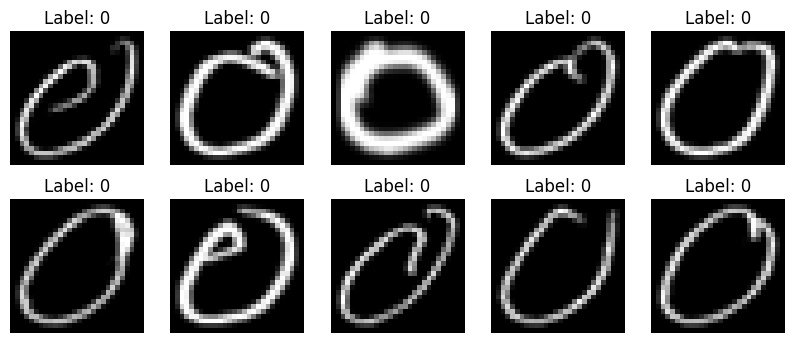

In [50]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image

#defining dayaset paths
train_dir = "/content/drive/MyDrive/AIML/Data/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AIML/Data/DevanagariHandwrittenDigitDataset/Test"
img_height, img_width = 28, 28
#funciton to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) #sorted class names
  class_map = {name: i for i, name in enumerate(class_names)}
  for class_name in class_names:
    class_path = os.path.join(folder, class_name)
    label = class_map[class_name]
    for filename in os.listdir(class_path):
      img_path = os.path.join(class_path, filename)
      #loading image using PIL
      img = Image.open(img_path).convert("L") #convert to grayscale
      img = img.resize((img_width, img_height)) # resizing to (28,28)
      img = np.array(img) / 255.0
      images.append(img)
      labels.append(label)
  return np.array(images), np.array(labels)
#loading training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

#reshaping images for keras input
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

#one-hot encode lables
y_train = to_categorical(y_train, num_classes = 10)
y_test = to_categorical(y_test, num_classes = 10)
#printing dataset shape
print(f"Training set: {x_train.shape}, labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, lables: {y_test.shape}")

plt.figure(figsize = (10,4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28,28), cmap = 'gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("Off")
plt.show()


## Loading and Preprocessing Mnist Handwritten Digit Dataset

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Example using Squential API

In [6]:
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential([keras.layers.Input(shape=input_shape), keras.layers.Flatten(), keras.layers.Dense(64, activation="sigmoid"), keras.layers.Dense(128, activation="sigmoid"), keras.layers.Dense(256, activation="sigmoid"), keras.layers.Dense(num_classes, activation="softmax"),])

# Build the Model

In [7]:
import tensorflow as tf
from tensorflow import keras
model = keras.Sequential([
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Functional API

In [8]:
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
def build_functional_model():
  inputs = keras.Input(shape=input_shape)
  x = keras.layers.Flatten()(inputs)
  x = keras.layers.Dense(64, activation="sigmoid")(x)
  x = keras.layers.Dense(128, activation="sigmoid")(x)
  x = keras.layers.Dense(256, activation="sigmoid")(x)
  outputs = keras.layers.Dense(num_classes, activation="softmax")(x)
  model = keras.Model(inputs=inputs, outputs=outputs)
  return model
# Building the model
functional_model = build_functional_model()
functional_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## compiling model

In [16]:
model.compile( optimizer="Adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Parameter and Setup

In [17]:
batch_size = 128 #number of training samples to process before updating models weight
epochs = 20

# Reshape x_train and x_test to match the model's expected input shape
x_train_reshaped = x_train.reshape(-1, 28, 28, 1)
x_test_reshaped = x_test.reshape(-1, 28, 28, 1)

# Re-define the model to ensure it's fresh for each run
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential([
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax")
])

# Re-compile the model
model.compile( optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

#callbacks
callbacks = [keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"), keras.callbacks.EarlyStopping(monitor="val_loss", patience=4)]
history = model.fit(
x_train_reshaped,
y_train,
batch_size=batch_size,
epochs=epochs,
validation_split=0.2,
callbacks=callbacks,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1106 - loss: 2.3079 - val_accuracy: 0.0922 - val_loss: 2.3010
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1120 - loss: 2.2999 - val_accuracy: 0.1060 - val_loss: 2.2994
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1155 - loss: 2.2983 - val_accuracy: 0.1060 - val_loss: 2.2975
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1194 - loss: 2.2966 - val_accuracy: 0.1060 - val_loss: 2.2965
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1181 - loss: 2.2950 - val_accuracy: 0.1226 - val_loss: 2.2940
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1254 - loss: 2.2926 - val_accuracy: 0.1799 - val_loss: 2.2918
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1274 - loss: 2.2907 - val_accuracy: 0.1060 - val_loss: 2.2900
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1332 - loss: 2.2884 - val_accuracy: 0.

## Visualizing models training progress

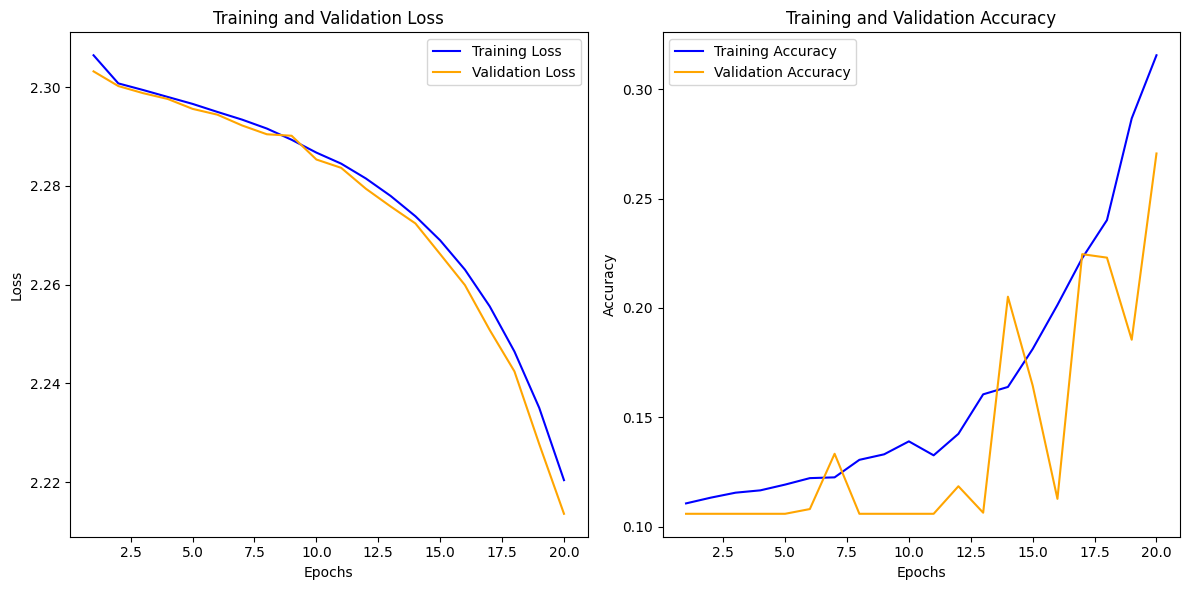

In [11]:
import matplotlib.pyplot as plt
# Assuming ’history’ is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluating the model

In [12]:
test_loss, test_acc = model.evaluate(x_test_reshaped, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 2s - 7ms/step - accuracy: 0.2847 - loss: 2.2101
Test accuracy: 0.2847


# Model Predict

In [13]:
# Predict on test data
predictions = model.predict(x_test_reshaped)
# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted label for first image: 1
True label for first image: 7


# Saving and Loading the model

In [14]:
model.save('mnist_fully_connected_model.h5')

In [15]:
loaded_model = tf.keras.models.load_model('mnist_fully_connected_model.h5')